# Fase 1 - Actividad 1: Exploración y Validación Estructural del Corpus

Esta actividad inicial se centra en:
- Adquisición y carga del conjunto de datos crudos locales sobre desinformación política en español.
- Validación de su integridad estructural.
- Análisis de la distribución de longitudes de las noticias (conteo de palabras y caracteres).
- Cuantificación gráfica del desbalance nativo entre las categorías de noticias falsas y verdaderas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de estilo para gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga de Datos y Validación Estructural

In [2]:
# Carga de registros desde el archivo original (OG)
try:
    df_raw = pd.read_csv('data/PoliticalFakeNews_OG.csv', sep=';')
    print("Datos crudos cargados exitosamente.")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

# Verificar integridad estructural
print(f"\nDimensiones del corpus: {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas.")
print("\nInformación general de los tipos de datos y valores nulos:")
df_raw.info()

Datos crudos cargados exitosamente.

Dimensiones del corpus: 57231 filas y 5 columnas.

Información general de los tipos de datos y valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 57231 entries, 0 to 57230
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           57231 non-null  str  
 1   Label        57231 non-null  int64
 2   Titulo       57231 non-null  str  
 3   Descripcion  57231 non-null  str  
 4   Fecha        57231 non-null  str  
dtypes: int64(1), str(4)
memory usage: 2.2 MB


In [3]:
df_raw.head()

,ID,Label,Titulo,Descripcion,Fecha
0,ID,1,Moreno intenta apaciguar el flanco sanitario m...,El presidente abre la puerta a unos comicios e...,19/04/2022
1,ID,1,La Abogacía del Estado se retira como acusació...,"En un escrito, la abogada del Estado Rosa Marí...",17/09/2021
2,ID,0,Las promesas incumplidas de Pablo Echenique en...,Este lunes y martes la Asamblea de Madrid acog...,12/09/2022
3,ID,1,Sánchez defiende 'resolver el problema' de la ...,Resulta evidente que la ley ha tenido algunos ...,07/02/2023
4,ID,1,Ian Gibson cierra la lista electoral de la con...,"El hispanista, que ya ocupó un puesto simbólic...",12/04/2023


## 2. Análisis de Distribuciones Léxicas

In [4]:
# Rellenar nulos temporalmente para evitar errores en conteos precisos
df_eda = df_raw.copy()
df_eda['Titulo'] = df_eda['Titulo'].fillna('')
df_eda['Descripcion'] = df_eda['Descripcion'].fillna('')

# Conteo de Caracteres
df_eda['len_char_titulo'] = df_eda['Titulo'].apply(len)
df_eda['len_char_desc'] = df_eda['Descripcion'].apply(len)

# Conteo de Palabras
df_eda['len_words_titulo'] = df_eda['Titulo'].apply(lambda x: len(x.split()))
df_eda['len_words_desc'] = df_eda['Descripcion'].apply(lambda x: len(x.split()))

print("Estadísticas descriptivas de la longitud léxica:")
display(df_eda[['len_words_titulo', 'len_words_desc', 'len_char_titulo', 'len_char_desc']].describe())

Estadísticas descriptivas de la longitud léxica:


,len_words_titulo,len_words_desc,len_char_titulo,len_char_desc
count,57231.000000,57231.000000,57231.000000,57231.000000
mean,16.180269,37.874054,95.029879,228.737817
std,3.944112,15.098848,21.663493,90.718050
min,3.000000,4.000000,12.000000,33.000000
25%,14.000000,28.000000,80.000000,171.000000
50%,16.000000,36.000000,95.000000,220.000000
75%,19.000000,44.000000,111.000000,266.000000
max,37.000000,178.000000,212.000000,1034.000000


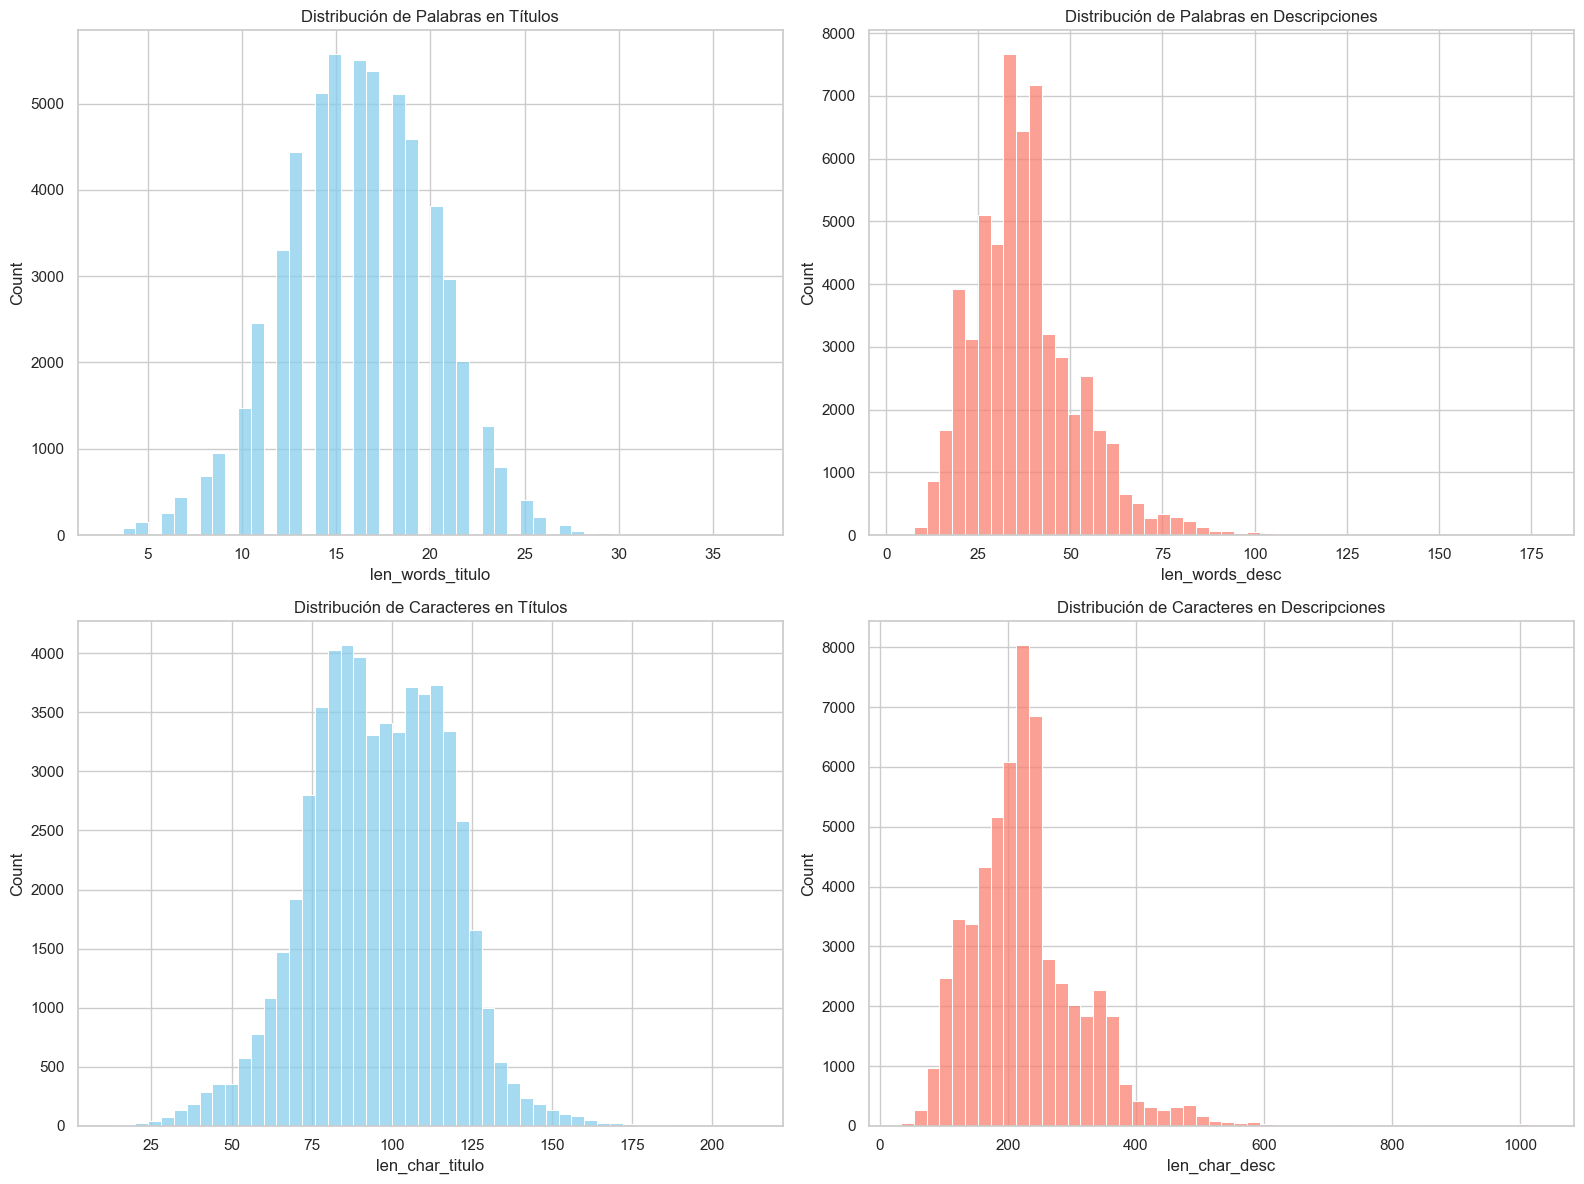

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_eda['len_words_titulo'], bins=50, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribución de Palabras en Títulos')

sns.histplot(df_eda['len_words_desc'], bins=50, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Distribución de Palabras en Descripciones')

sns.histplot(df_eda['len_char_titulo'], bins=50, ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Distribución de Caracteres en Títulos')

sns.histplot(df_eda['len_char_desc'], bins=50, ax=axes[1,1], color='salmon')
axes[1,1].set_title('Distribución de Caracteres en Descripciones')

plt.tight_layout()
plt.show()

## 3. Cuantificación del Desbalance de Clases

Desbalance nativo de clases:


,Cantidad,Porcentaje (%)
Label,,
1,33351,58.274362
0,23880,41.725638


C:\Users\Baller 293\AppData\Local\Temp\ipykernel_21620\3180193304.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_raw, x='Label', palette='viridis')


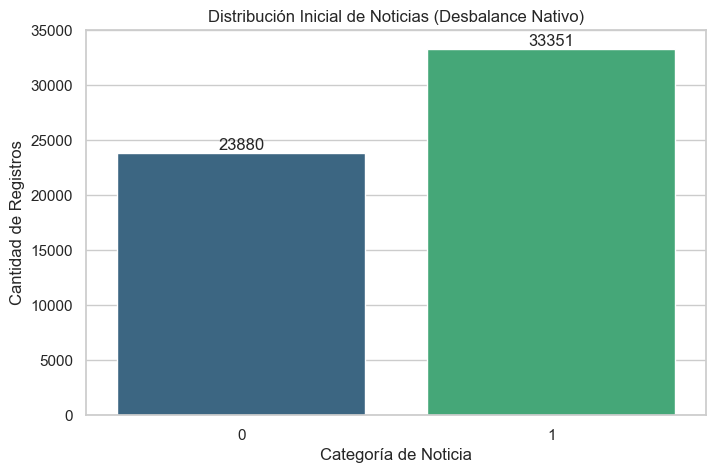

In [6]:
# Distribución numérica
class_counts = df_raw['Label'].value_counts()
class_percentages = df_raw['Label'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Cantidad': class_counts, 'Porcentaje (%)': class_percentages})
print("Desbalance nativo de clases:")
display(dist_df)

# Gráfico del desbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_raw, x='Label', palette='viridis')
plt.title('Distribución Inicial de Noticias (Desbalance Nativo)')
plt.xlabel('Categoría de Noticia')
plt.ylabel('Cantidad de Registros')

# Agregar etiquetas de valor en las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()